# WWW 마케팅 분석 포트폴리오 완성형 노트북

이 노트북은 기존 `www_final.ipynb`, `www_final2.ipynb`의 흐름을 합쳐서  
**실행 안정성 + 데이터 검증 + WWW 구조 + 핵심 가설 검증**까지 한 번에 볼 수 있도록 정리한 버전

## 이 노트북의 목표
- **Who**: 어떤 고객/세그먼트가 상대적으로 강한가?
- **When**: 오퍼를 본 뒤 얼마나 빨리 반응하는가?
- **Why**: 어떤 오퍼 속성이 전환과 연결되는가?
- **가설 검증**
  1. 고연령/고소득 그룹은 핵심 타겟 후보인가?
  2. 구매 행동은 오퍼 반응형 / 자연 구매형으로 나눠서 볼 수 있는가?
  3. 자연 구매 성향이 높은 그룹은 할인 외 전략 검토가 필요한가?

> 주의: 이 분석은 **offer instance 단위 분석**과 **customer 단위 요약 분석**을 분리해서 본다.
> 즉, "행동 유형"과 "고객 유형"을 섞지 않도록 구조를 정리

## 0. 분석 전에 먼저 확인할 점

아래 코드 셀에서는 다음을 준비

1. 라이브러리 import  
2. 한글 폰트 설정 (운영체제에 따라 자동 탐색)  
3. CSV 파일 경로 확인  
4. 출력 옵션 설정  

기존 노트북의 문제였던 **Windows 전용 폰트 하드코딩**은 제거

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# 출력 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 그래프 기본 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

# 운영체제에 따라 한글 폰트를 자동으로 찾도록 설정
candidate_fonts = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
available_fonts = {f.name for f in fm.fontManager.ttflist}

selected_font = None
for font_name in candidate_fonts:
    if font_name in available_fonts:
        selected_font = font_name
        plt.rcParams['font.family'] = font_name
        break

print('선택된 폰트:', selected_font if selected_font else '기본 폰트 사용')

선택된 폰트: Malgun Gothic


## 1. 데이터 불러오기
- `funnel_instance.csv`
- `final_eda.csv`

In [2]:
# 현재 노트북 기준으로 자주 사용하는 경로 후보를 순서대로 확인
candidate_dirs = [
    Path('.'),
    Path('./data'),
    Path('/mnt/data')
]

funnel_path = None
eda_path = None

for base_dir in candidate_dirs:
    f1 = base_dir / 'funnel_instance.csv'
    f2 = base_dir / 'final_eda.csv'
    if f1.exists() and f2.exists():
        funnel_path = f1
        eda_path = f2
        break

if funnel_path is None or eda_path is None:
    raise FileNotFoundError(
        "funnel_instance.csv 와 final_eda.csv 를 찾지 못했습니다. "
        "노트북과 같은 폴더 또는 ./data 폴더에 두 파일을 넣고 다시 실행해 주세요."
    )

print('funnel path :', funnel_path)
print('eda path    :', eda_path)

funnel = pd.read_csv(funnel_path)
eda = pd.read_csv(eda_path)

print('funnel shape :', funnel.shape)
print('eda shape    :', eda.shape)

funnel path : funnel_instance.csv
eda path    : final_eda.csv
funnel shape : (76277, 21)
eda shape    : (306534, 29)


In [3]:
# 컬럼 구조를 먼저 확인해서 이후 merge / 파생변수 분석이 가능한지 점검
print('[funnel columns]')
print(funnel.columns.tolist())

print('\n[eda columns]')
print(eda.columns.tolist())

[funnel columns]
['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'gap_view_to_complete']

[eda columns]
['customer_id', 'event', 'time', 'amount', 'actual_reward', 'offer_id', 'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength', 'gender', 'age', 'became_member_on', 'income', 'is_profile_missing', 'age_group', 'age_gender', 'income_group', 'join_year', 'join_month', 'join_cohort']


## 2. lookup 테이블 만들기 전, key 품질 점검

아래 코드 셀에서는

- `customer_id`
- `offer_id`

기준으로 고객 lookup / 오퍼 lookup 을 만들기 전에  
중복과 누락 여부를 먼저 확인

> merge 후 row 수가 예상과 다르게 늘어나거나 줄어드는 문제를 예방하는 데 중요

In [4]:
# 고객 lookup 에 사용할 컬럼
cust_cols = [
    'customer_id',
    'gender', 'age', 'income',
    'age_group', 'income_group'
]

# 오퍼 lookup 에 사용할 컬럼
offer_cols = [
    'offer_id',
    'offer_type',
    'difficulty', 'reward',
    'ch_web', 'ch_email', 'ch_mobile', 'ch_social',
    'channel_count', 'reward_ratio', 'offer_strength'
]

# 필요한 컬럼이 실제로 존재하는지 확인
missing_cust_cols = [c for c in cust_cols if c not in eda.columns]
missing_offer_cols = [c for c in offer_cols if c not in eda.columns]

if missing_cust_cols:
    raise KeyError(f'eda에 없는 고객 컬럼: {missing_cust_cols}')
if missing_offer_cols:
    raise KeyError(f'eda에 없는 오퍼 컬럼: {missing_offer_cols}')

# 고객 / 오퍼 lookup 생성
cust_df = eda[cust_cols].drop_duplicates(subset=['customer_id']).copy()
offer_df = eda[offer_cols].drop_duplicates(subset=['offer_id']).copy()

print('cust_df shape :', cust_df.shape)
print('offer_df shape:', offer_df.shape)

print('\n[cust_df customer_id 중복 개수]')
print(cust_df.duplicated('customer_id').sum())

print('\n[offer_df offer_id 중복 개수]')
print(offer_df.duplicated('offer_id').sum())

cust_df shape : (17000, 6)
offer_df shape: (11, 11)

[cust_df customer_id 중복 개수]
0

[offer_df offer_id 중복 개수]
0


## 3. merge 수행 + row 폭발 여부 점검
1. 고객 merge 후 row 수가 유지되는가?  
2. 오퍼 merge 후 row 수가 유지되는가?  
3. merge 후 누락률은 어느 정도인가?  
4. `offer_type_x`, `offer_type_y` 같은 중복 컬럼이 생기면 안전하게 정리하는가?

In [5]:
# merge 전 원본 row 수를 기억해 둠
before_rows = len(funnel)

# 1차 merge: customer 정보 연결
base_df = funnel.merge(
    cust_df,
    on='customer_id',
    how='left',
    validate='m:1'
)

after_customer_merge_rows = len(base_df)

# 2차 merge: offer 정보 연결
base_df = base_df.merge(
    offer_df,
    on='offer_id',
    how='left',
    validate='m:1',
    suffixes=('', '_offer')
)

after_offer_merge_rows = len(base_df)

print('merge 전 row 수               :', before_rows)
print('customer merge 후 row 수     :', after_customer_merge_rows)
print('offer merge 후 row 수        :', after_offer_merge_rows)

if before_rows != after_customer_merge_rows:
    print('주의: customer merge 후 row 수가 변경되었습니다.')
if before_rows != after_offer_merge_rows:
    print('주의: offer merge 후 row 수가 변경되었습니다.')

merge 전 row 수               : 76277
customer merge 후 row 수     : 76277
offer merge 후 row 수        : 76277


In [6]:
# offer_type 중복 컬럼이 생기는 경우를 안전하게 처리
# 원래 funnel에 offer_type이 있고, offer lookup에도 offer_type이 있으면 중복이 생길 수 있음
if 'offer_type_offer' in base_df.columns:
    # 두 컬럼이 모두 있으면 값이 같은지 먼저 점검
    same_ratio = (base_df['offer_type'].astype(str) == base_df['offer_type_offer'].astype(str)).mean()
    print('offer_type 일치 비율:', round(same_ratio, 4))

    # 최종적으로는 원래 offer_type 하나만 남김
    # 값이 비어 있는 경우를 대비해 combine_first 사용
    base_df['offer_type'] = base_df['offer_type'].combine_first(base_df['offer_type_offer'])
    base_df = base_df.drop(columns=['offer_type_offer'])

print(base_df.columns.tolist())

offer_type 일치 비율: 1.0
['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'is_viewed', 'is_completed', 'completed_without_prior_view', 'gap_view_to_complete', 'gender', 'age', 'income', 'age_group', 'income_group', 'difficulty', 'reward', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength']


In [7]:
# merge 후 누락률 점검
check_cols = [
    'gender', 'age_group', 'income_group',
    'offer_type', 'difficulty', 'reward', 'reward_ratio', 'offer_strength'
]

missing_report = base_df[check_cols].isna().mean().sort_values(ascending=False)
missing_report.to_frame('missing_rate')

,missing_rate
gender,0.0
age_group,0.0
income_group,0.0
offer_type,0.0
difficulty,0.0
reward,0.0
reward_ratio,0.0
offer_strength,0.0


## 4. 분석용 데이터프레임 분리

기존 노트북에서는 하나의 `df` 안에서 여러 목적을 섞어 사용  
이번에는 목적별로 나눔

- `base_df` : 전체 offer instance 기준 분석용
- `responsive_df` : 오퍼를 보고 구매한 사례 중심 분석용
- `completed_df` : 구매 완료된 사례만 분석용
- `customer_level_df` : 고객 단위 요약 분석용

"행동 유형" | "고객 유형"

In [8]:
# 전체 분석용
base_df = base_df.copy()

# completed_without_prior_view 값이 있는 경우에만 행동 유형 분류
# 1 = 오퍼 보기 전에 완료됨(자연 구매 성향)
# 0 = 보기 이후 완료 또는 자연구매 아님
conditions = [
    (base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 0),
    (base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 1),
    (base_df['is_completed'] == 0)
]
choices = ['Offer_Responsive', 'Natural_Purchase', 'Not_Completed']

base_df['behavior_type'] = np.select(conditions, choices, default='Other')

# 오퍼를 보고 반응한 사례 중심 분석용
responsive_df = base_df[
    (base_df['is_completed'] == 1) &
    (base_df['completed_without_prior_view'] == 0)
].copy()

# 완료 사례 전체
completed_df = base_df[base_df['is_completed'] == 1].copy()

print('base_df shape      :', base_df.shape)
print('responsive_df shape:', responsive_df.shape)
print('completed_df shape :', completed_df.shape)

base_df['behavior_type'].value_counts(dropna=False)

base_df shape      : (76277, 36)
responsive_df shape: (23267, 36)
completed_df shape : (33101, 36)


behavior_type
Not_Completed       43176
Offer_Responsive    23267
Natural_Purchase     9834
Name: count, dtype: int64

In [9]:
# 고객 단위 요약 테이블 생성
# 여기서는 고객별로 "어떤 행동이 상대적으로 많은지"를 보기 위함
customer_level_df = (
    base_df.assign(
        offer_responsive_flag=((base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 0)).astype(int),
        natural_purchase_flag=((base_df['is_completed'] == 1) & (base_df['completed_without_prior_view'] == 1)).astype(int),
        completed_flag=(base_df['is_completed'] == 1).astype(int)
    )
    .groupby('customer_id')
    .agg(
        n_offers=('offer_id', 'count'),
        completed_cnt=('completed_flag', 'sum'),
        responsive_cnt=('offer_responsive_flag', 'sum'),
        natural_cnt=('natural_purchase_flag', 'sum'),
        gender=('gender', 'first'),
        age_group=('age_group', 'first'),
        income_group=('income_group', 'first'),
        age=('age', 'first'),
        income=('income', 'first')
    )
    .reset_index()
)

# 고객 단위 비율 계산
customer_level_df['completion_rate_by_customer'] = customer_level_df['completed_cnt'] / customer_level_df['n_offers']
customer_level_df['responsive_share'] = customer_level_df['responsive_cnt'] / customer_level_df['n_offers']
customer_level_df['natural_share'] = customer_level_df['natural_cnt'] / customer_level_df['n_offers']

# 고객 단위의 대표 성향 라벨
customer_level_df['customer_type'] = np.select(
    [
        customer_level_df['responsive_share'] >= 0.6,
        customer_level_df['natural_share'] >= 0.6
    ],
    ['Offer_Responsive_Customer', 'Natural_Purchase_Customer'],
    default='Mixed'
)

customer_level_df.head()

,customer_id,n_offers,completed_cnt,responsive_cnt,natural_cnt,gender,age_group,income_group,age,income,completion_rate_by_customer,responsive_share,natural_share,customer_type
0,0009655768c64bdeb2e877511632db8f,5,3,0,3,M,30대,5-7.5만,33.0,72000.0,0.60,0.00,0.6,Natural_Purchase_Customer
1,00116118485d4dfda04fdbaba9a87b5c,2,0,0,0,Unknown,누락,누락,NaN,0.0,0.00,0.00,0.0,Mixed
2,0011e0d4e6b944f998e987f904e8c1e5,5,3,3,0,O,40대,5-7.5만,40.0,57000.0,0.60,0.60,0.0,Offer_Responsive_Customer
3,0020c2b971eb4e9188eac86d93036a77,5,3,2,1,F,50대,7.5-10만,59.0,90000.0,0.60,0.40,0.2,Mixed
4,0020ccbbb6d84e358d3414a3ff76cffd,4,3,3,0,F,20대,5-7.5만,24.0,60000.0,0.75,0.75,0.0,Offer_Responsive_Customer


## 5. 핵심 세그먼트 정의

기존 분석의 핵심 가설인 **고연령 + 고소득 그룹**을 그대로 사용하되,  
이번에는 다음 두 수준에서 확인

1. **instance 기준 세그먼트** (`base_df`)  
2. **customer 기준 세그먼트** (`customer_level_df`)  

>"행동 row 기준으로 많이 보인 것인지",  
>> OR "고객 자체가 정말 강한 것인지"를 조금 더 구분해서 해석

In [10]:
# instance 기준 세그먼트
base_df['is_high_age'] = base_df['age_group'].isin(['50대', '60대 이상'])
base_df['is_high_income'] = base_df['income_group'].isin(['7.5-10만', '10만 이상'])

base_df['target_segment'] = np.where(
    base_df['is_high_age'] & base_df['is_high_income'],
    'HighAge_HighIncome',
    'Others'
)

# customer 기준 세그먼트
customer_level_df['is_high_age'] = customer_level_df['age_group'].isin(['50대', '60대 이상'])
customer_level_df['is_high_income'] = customer_level_df['income_group'].isin(['7.5-10만', '10만 이상'])

customer_level_df['target_segment'] = np.where(
    customer_level_df['is_high_age'] & customer_level_df['is_high_income'],
    'HighAge_HighIncome',
    'Others'
)

print('[instance 기준]')
display(base_df['target_segment'].value_counts(dropna=False))

print('[customer 기준]')
display(customer_level_df['target_segment'].value_counts(dropna=False))

[instance 기준]


target_segment
Others                58537
HighAge_HighIncome    17740
Name: count, dtype: int64

[customer 기준]


target_segment
Others                13028
HighAge_HighIncome     3966
Name: count, dtype: int64

# 6. WHO 분석

>"누가 더 잘 반응하는가?"

- 성별 / 연령대별 완료율
- 고연령/고소득 세그먼트의 성과
- 고객 단위에서 봐도 같은 방향성이 나오는지 확인

In [11]:
# 성별 기준 요약
who_gender = (
    base_df.groupby('gender')
    .agg(
        n=('customer_id', 'count'),
        viewed_rate=('is_viewed', 'mean'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

who_gender

,n,viewed_rate,completion_rate
gender,,,
F,27456,0.739183,0.557146
O,916,0.839520,0.538210
M,38129,0.728553,0.425136
Unknown,9776,0.790098,0.112623


In [12]:
# 연령대 기준 요약
who_age = (
    base_df.groupby('age_group')
    .agg(
        n=('customer_id', 'count'),
        viewed_rate=('is_viewed', 'mean'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

who_age

,n,viewed_rate,completion_rate
age_group,,,
50대,15894,0.739147,0.513464
60대 이상,26331,0.736204,0.510007
40대,10288,0.776925,0.465397
30대,6893,0.709125,0.429421
20대,6174,0.679138,0.380143
20대 미만,921,0.690554,0.342020
누락,9776,0.790098,0.112623


offer_type,bogo,discount,informational
age_group,,,
20대,0.427,0.511,0.0
20대 미만,0.367,0.513,0.0
30대,0.494,0.578,0.0
40대,0.549,0.614,0.0
50대,0.622,0.664,0.0
60대 이상,0.605,0.672,0.0
누락,0.101,0.180,0.0


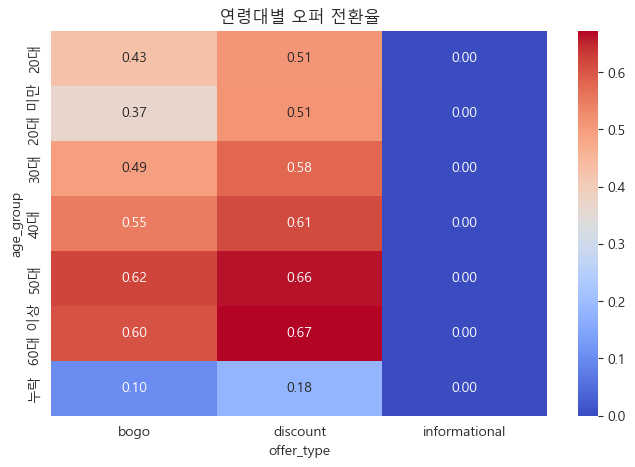

In [13]:
# 연령대 x 오퍼유형 heatmap
pivot_age_offer = base_df.pivot_table(
    index='age_group',
    columns='offer_type',
    values='is_completed',
    aggfunc='mean'
)

pivot_age_offer = pivot_age_offer.round(3)
display(pivot_age_offer)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_age_offer, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('연령대별 오퍼 전환율')
plt.xlabel('offer_type')
plt.ylabel('age_group')
plt.show()

In [14]:
# 핵심 세그먼트 요약 - instance 기준
target_summary_instance = (
    base_df.groupby('target_segment')
    .agg(
        n=('customer_id', 'count'),
        viewed_rate=('is_viewed', 'mean'),
        completion_rate=('is_completed', 'mean'),
        natural_purchase_rate=('completed_without_prior_view', 'mean')
    )
    .reset_index()
)

target_summary_instance

,target_segment,n,viewed_rate,completion_rate,natural_purchase_rate
0,HighAge_HighIncome,17740,0.726719,0.600056,0.203890
1,Others,58537,0.746109,0.383621,0.106206


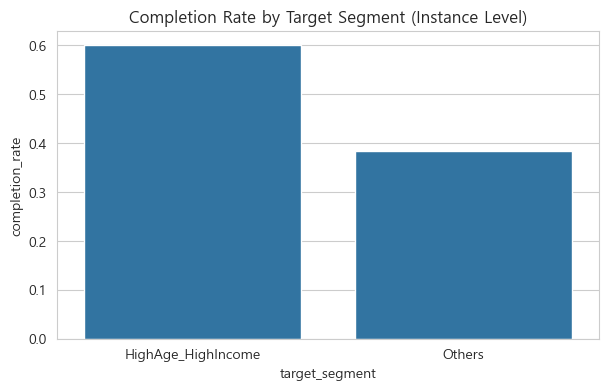

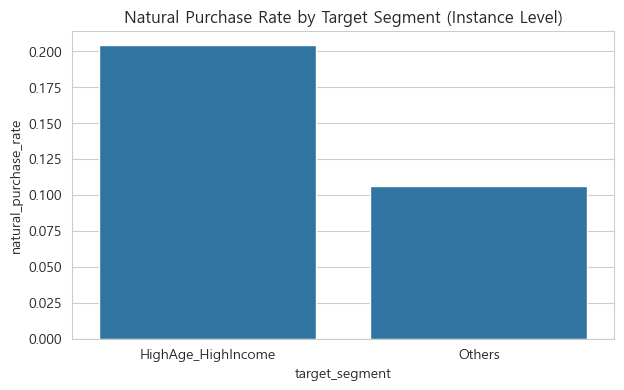

In [15]:
plt.figure(figsize=(7, 4))
sns.barplot(data=target_summary_instance, x='target_segment', y='completion_rate')
plt.title('Completion Rate by Target Segment (Instance Level)')
plt.ylabel('completion_rate')
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=target_summary_instance, x='target_segment', y='natural_purchase_rate')
plt.title('Natural Purchase Rate by Target Segment (Instance Level)')
plt.ylabel('natural_purchase_rate')
plt.show()

In [16]:
# 핵심 세그먼트 요약 - customer 기준
target_summary_customer = (
    customer_level_df.groupby('target_segment')
    .agg(
        customers=('customer_id', 'count'),
        avg_completion_rate=('completion_rate_by_customer', 'mean'),
        avg_responsive_share=('responsive_share', 'mean'),
        avg_natural_share=('natural_share', 'mean')
    )
    .reset_index()
)

target_summary_customer

,target_segment,customers,avg_completion_rate,avg_responsive_share,avg_natural_share
0,HighAge_HighIncome,3966,0.599571,0.397563,0.202009
1,Others,13028,0.383694,0.279387,0.104307


## WHO 통계 검정

>instance 기준으로 고연령/고소득 vs 기타 그룹의 완료율 차이를 간단한 비율검정으로 확인

#### 해석 주의  
> 이 검정은 **offer instance 기준**이며, 반복 관측 문제까지 완벽히 해결하는 검정은 아님
>> 그래도 현재 코드 수준에서는 핵심 세그먼트 차이를 빠르게 확인하는 용도로 충분히 의미가 있음

In [17]:
grp = base_df.groupby('target_segment')['is_completed'].agg(['sum', 'count'])
grp

,sum,count
target_segment,,
HighAge_HighIncome,10645,17740
Others,22456,58537


In [18]:
count = grp['sum'].values
nobs = grp['count'].values

stat, pval = proportions_ztest(count=count, nobs=nobs)

print('z-stat :', stat)
print('p-value:', pval)

if pval < 0.05:
    print('=> 두 그룹의 완료율 차이는 통계적으로 유의하다고 볼 수 있습니다.')
else:
    print('=> 두 그룹의 완료율 차이가 통계적으로 유의하다고 보기 어렵습니다.')

z-stat : 50.95374221241875
p-value: 0.0
=> 두 그룹의 완료율 차이는 통계적으로 유의하다고 볼 수 있습니다.


# 7. WHY 분석

> "무엇이 전환과 연결되는가?"

- 오퍼 유형별 완료율
- reward_ratio / difficulty / reward / offer_strength 와의 관계
- 행동 유형별 오퍼 mix 비교

In [19]:
why_offer = (
    base_df.groupby('offer_type')
    .agg(
        n=('customer_id', 'count'),
        completion_rate=('is_completed', 'mean'),
        viewed_rate=('is_viewed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

why_offer

,n,completion_rate,viewed_rate
offer_type,,,
discount,30543,0.576237,0.699669
bogo,30499,0.508246,0.827896
informational,15235,0.000000,0.652904


In [20]:
# 숫자형 오퍼 속성별 평균 완료율 비교
reward_ratio_summary = (
    base_df.groupby('reward_ratio')
    .agg(
        n=('customer_id', 'count'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

difficulty_summary = (
    base_df.groupby('difficulty')
    .agg(
        n=('customer_id', 'count'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

reward_summary = (
    base_df.groupby('reward')
    .agg(
        n=('customer_id', 'count'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

offer_strength_summary = (
    base_df.groupby('offer_strength')
    .agg(
        n=('customer_id', 'count'),
        completion_rate=('is_completed', 'mean')
    )
    .sort_values('completion_rate', ascending=False)
)

print('[reward_ratio]')
display(reward_ratio_summary)

print('[difficulty]')
display(difficulty_summary)

print('[reward]')
display(reward_summary)

print('[offer_strength]')
display(offer_strength_summary)

[reward_ratio]


,n,completion_rate
reward_ratio,,
0.428571,7646,0.667277
0.200000,15229,0.603126
1.000000,30499,0.508246
0.250000,7668,0.432055
0.000000,15235,0.000000


[difficulty]


,n,completion_rate
difficulty,,
7.0,7646,0.667277
5.0,15248,0.561713
10.0,30480,0.528904
20.0,7668,0.432055
0.0,15235,0.000000


[reward]


,n,completion_rate
reward,,
3.0,7646,0.667277
2.0,15229,0.603126
5.0,22916,0.518328
10.0,15251,0.454790
0.0,15235,0.000000


[offer_strength]


,n,completion_rate
offer_strength,,
-4.0,7646,0.667277
-8.0,15229,0.603126
-15.0,7668,0.432055
0.0,45734,0.338938


In [21]:
# 완료 사례에서 행동 유형별 오퍼 mix 비교
offer_mix = pd.crosstab(
    completed_df['behavior_type'],
    completed_df['offer_type'],
    normalize='index'
)

offer_mix

offer_type,bogo,discount
behavior_type,,
Natural_Purchase,0.463697,0.536303
Offer_Responsive,0.470237,0.529763


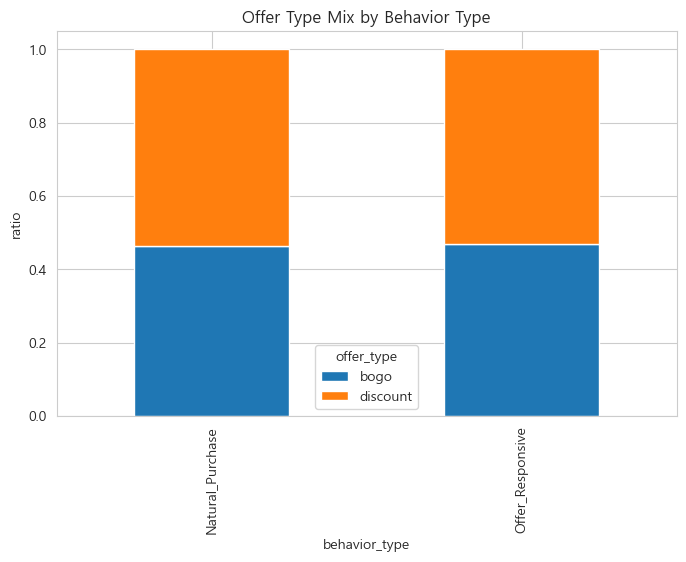

In [22]:
offer_mix.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Offer Type Mix by Behavior Type')
plt.ylabel('ratio')
plt.show()

## 행동 유형과 세그먼트의 관계

**고연령/고소득 세그먼트에서 자연 구매/오퍼 반응형 비중이 다른가?** 

In [23]:
type_by_target = pd.crosstab(
    base_df['target_segment'],
    base_df['behavior_type'],
    normalize='index'
)

type_by_target

behavior_type,Natural_Purchase,Not_Completed,Offer_Responsive
target_segment,,,
HighAge_HighIncome,0.203890,0.399944,0.396167
Others,0.106206,0.616379,0.277414


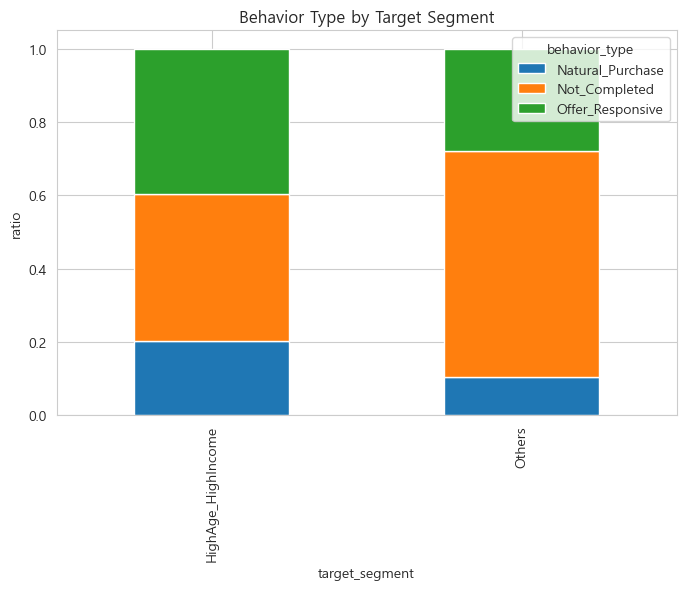

In [24]:
type_by_target.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Behavior Type by Target Segment')
plt.ylabel('ratio')
plt.show()

In [25]:
cont_table = pd.crosstab(base_df['target_segment'], base_df['behavior_type'])
cont_table

behavior_type,Natural_Purchase,Not_Completed,Offer_Responsive
target_segment,,,
HighAge_HighIncome,3617,7095,7028
Others,6217,36081,16239


In [36]:
chi2, pval, dof, expected = chi2_contingency(cont_table)

print('chi2   :', chi2)
print('p-value:', pval)
print('dof    :', dof)

if pval < 0.05:
    print('=> 세그먼트와 행동 유형 분포는 독립이라고 보기 어려움')
else:
    print('=> 세그먼트와 행동 유형 분포 차이가 뚜렷하다고 보기 어려움')

chi2   : 2763.6943398629396
p-value: 0.0
dof    : 2
=> 세그먼트와 행동 유형 분포는 독립이라고 보기 어려움


# 8. WHEN 분석

> **"얼마나 빨리 반응하는가"**

복잡한 시간대 분석 대신 **<오퍼를 본 뒤 완료까지 걸리는 시간 차이>**

In [27]:
# 오퍼를 보고 구매한 사례만 대상으로 view -> complete 시간 차이를 분석
responsive_time_df = base_df[
    (base_df['behavior_type'] == 'Offer_Responsive') &
    (base_df['gap_view_to_complete'].notna())
].copy()

responsive_time_df[['offer_type', 'gap_view_to_complete']].head()

,offer_type,gap_view_to_complete
7,discount,144.0
8,discount,66.0
11,bogo,60.0
12,bogo,84.0
15,discount,42.0


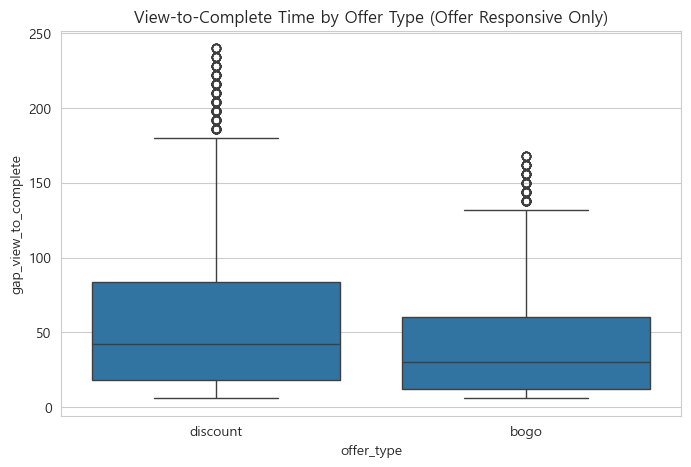

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=responsive_time_df, x='offer_type', y='gap_view_to_complete')
plt.title('View-to-Complete Time by Offer Type (Offer Responsive Only)')
plt.ylabel('gap_view_to_complete')
plt.show()

In [37]:
# BOGO vs Discount의 행동 속도 차이 검정
x = responsive_time_df.loc[responsive_time_df['offer_type'] == 'bogo', 'gap_view_to_complete']
y = responsive_time_df.loc[responsive_time_df['offer_type'] == 'discount', 'gap_view_to_complete']

# 두 그룹의 데이터가 모두 존재할 때만 검정
if len(x) > 0 and len(y) > 0:
    stat, pval = mannwhitneyu(x, y, alternative='two-sided')
    print('Mann-Whitney U:', stat)
    print('p-value       :', pval)

    if pval < 0.05:
        print('=> 두 오퍼의 반응 속도 분포 차이는 유의하다고 볼 수 있음')
    else:
        print('=> 두 오퍼의 반응 속도 차이가 유의하다고 보기 어려움.')
else:
    print('비교할 데이터가 부족')

Mann-Whitney U: 42782219.0
p-value       : 8.752133481182945e-115
=> 두 오퍼의 반응 속도 분포 차이는 유의하다고 볼 수 있음


In [30]:
# 반응 속도를 이해하기 쉽게 구간화
responsive_time_df['speed_group'] = pd.cut(
    responsive_time_df['gap_view_to_complete'],
    bins=[-1, 24, 72, 168, np.inf],
    labels=['Within_1d', '1to3d', '3to7d', 'Over_7d']
)

speed_summary = pd.crosstab(
    responsive_time_df['offer_type'],
    responsive_time_df['speed_group'],
    normalize='index'
)

speed_summary

speed_group,Within_1d,1to3d,3to7d,Over_7d
offer_type,,,,
bogo,0.431531,0.396048,0.172421,0.000000
discount,0.331567,0.364077,0.272564,0.031792


# 9. 고객 단위 관점 추가

> "오퍼 반응형 vs 자연 구매형"을 **진짜 고객 단위**에서 간단히 확인

In [31]:
customer_type_summary = (
    customer_level_df.groupby('customer_type')
    .agg(
        customers=('customer_id', 'count'),
        avg_completion_rate=('completion_rate_by_customer', 'mean'),
        avg_responsive_share=('responsive_share', 'mean'),
        avg_natural_share=('natural_share', 'mean')
    )
    .sort_values('customers', ascending=False)
)

customer_type_summary

,customers,avg_completion_rate,avg_responsive_share,avg_natural_share
customer_type,,,,
Mixed,13019,0.311006,0.198708,0.112297
Offer_Responsive_Customer,3410,0.830283,0.739218,0.091065
Natural_Purchase_Customer,565,0.878614,0.192684,0.685929


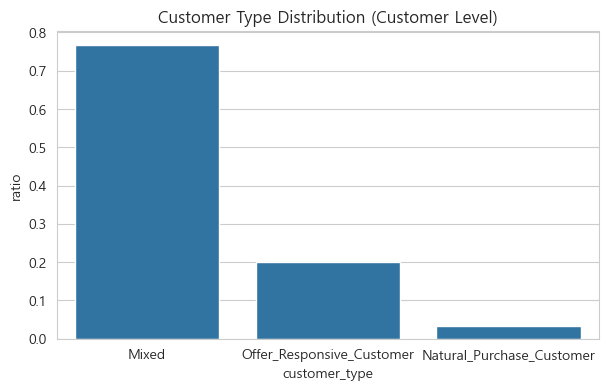

In [32]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=customer_level_df['customer_type'].value_counts(normalize=True).rename_axis('customer_type').reset_index(name='ratio'),
    x='customer_type',
    y='ratio'
)
plt.title('Customer Type Distribution (Customer Level)')
plt.ylabel('ratio')
plt.show()

In [33]:
customer_type_by_segment = pd.crosstab(
    customer_level_df['target_segment'],
    customer_level_df['customer_type'],
    normalize='index'
)

customer_type_by_segment

customer_type,Mixed,Natural_Purchase_Customer,Offer_Responsive_Customer
target_segment,,,
HighAge_HighIncome,0.665910,0.061019,0.273071
Others,0.796592,0.024793,0.178615


# 10. 최종 인사이트 테이블

- 핵심 타겟 세그먼트의 완료율
- 자연 구매 비율
- 행동 유형 분포
- 고객 단위 대표 성향 분포

In [34]:
final_segment_table = target_summary_instance.copy()

behavior_mix_table = pd.crosstab(
    base_df['target_segment'],
    base_df['behavior_type'],
    normalize='index'
).reset_index()

customer_mix_table = pd.crosstab(
    customer_level_df['target_segment'],
    customer_level_df['customer_type'],
    normalize='index'
).reset_index()

print('[1] 세그먼트 핵심 성과')
display(final_segment_table)

print('[2] 세그먼트별 행동 유형 분포 (instance 기준)')
display(behavior_mix_table)

print('[3] 세그먼트별 고객 성향 분포 (customer 기준)')
display(customer_mix_table)

[1] 세그먼트 핵심 성과


,target_segment,n,viewed_rate,completion_rate,natural_purchase_rate
0,HighAge_HighIncome,17740,0.726719,0.600056,0.203890
1,Others,58537,0.746109,0.383621,0.106206


[2] 세그먼트별 행동 유형 분포 (instance 기준)


behavior_type,target_segment,Natural_Purchase,Not_Completed,Offer_Responsive
0,HighAge_HighIncome,0.203890,0.399944,0.396167
1,Others,0.106206,0.616379,0.277414


[3] 세그먼트별 고객 성향 분포 (customer 기준)


customer_type,target_segment,Mixed,Natural_Purchase_Customer,Offer_Responsive_Customer
0,HighAge_HighIncome,0.665910,0.061019,0.273071
1,Others,0.796592,0.024793,0.178615


# 11. 해석 정리

 **자동 요약 문장**

In [35]:
best_age_group = who_age['completion_rate'].idxmax() if len(who_age) > 0 else None
best_offer_type = why_offer['completion_rate'].idxmax() if len(why_offer) > 0 else None

segment_completion = target_summary_instance.set_index('target_segment')['completion_rate'].to_dict()
segment_natural = target_summary_instance.set_index('target_segment')['natural_purchase_rate'].to_dict()

summary_text = f'''
[WHO]
- 완료율 기준으로 가장 강한 연령대는: {best_age_group}
- 고연령/고소득 세그먼트의 완료율: {round(segment_completion.get("HighAge_HighIncome", np.nan), 3)}
- 기타 세그먼트의 완료율: {round(segment_completion.get("Others", np.nan), 3)}

[WHY]
- 완료율 기준으로 가장 강한 오퍼 유형은: {best_offer_type}
- 고연령/고소득 세그먼트의 자연 구매 비율: {round(segment_natural.get("HighAge_HighIncome", np.nan), 3)}
- 기타 세그먼트의 자연 구매 비율: {round(segment_natural.get("Others", np.nan), 3)}

[WHEN]
- 반응 속도 비교는 Offer_Responsive 사례만 대상으로 수행
- BOGO vs Discount의 view-to-complete 차이는 Mann-Whitney 검정으로 확인

[해석 초안]
- 고연령/고소득 그룹은 완료율 측면에서 핵심 타겟 후보로 볼 수 있다.
- 다만 이 그룹은 자연 구매 비율도 함께 높을 수 있으므로, 무조건 할인만 강화하기보다 관계형/유지형 전략도 함께 검토할 필요가 있다.
- 오퍼 반응형 행동과 자연 구매 행동은 구분해서 보는 것이 마케팅 해석에 더 유리하다.
'''

print(summary_text)


[WHO]
- 완료율 기준으로 가장 강한 연령대는: 50대
- 고연령/고소득 세그먼트의 완료율: 0.6
- 기타 세그먼트의 완료율: 0.384

[WHY]
- 완료율 기준으로 가장 강한 오퍼 유형은: discount
- 고연령/고소득 세그먼트의 자연 구매 비율: 0.204
- 기타 세그먼트의 자연 구매 비율: 0.106

[WHEN]
- 반응 속도 비교는 Offer_Responsive 사례만 대상으로 수행
- BOGO vs Discount의 view-to-complete 차이는 Mann-Whitney 검정으로 확인

[해석 초안]
- 고연령/고소득 그룹은 완료율 측면에서 핵심 타겟 후보로 볼 수 있다.
- 다만 이 그룹은 자연 구매 비율도 함께 높을 수 있으므로, 무조건 할인만 강화하기보다 관계형/유지형 전략도 함께 검토할 필요가 있다.
- 오퍼 반응형 행동과 자연 구매 행동은 구분해서 보는 것이 마케팅 해석에 더 유리하다.

